## Initialization

In [1]:
# NEVER EVER DELETE THIS CELL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

import inspect

I started by importing the libraries I'd need for this project: Pandas and NumPy for handling the labels data, Matplotlib for visualization, and TensorFlow/Keras for building and training the image classification model. I'm using `ResNet50` as a pretrained backbone, since transfer learning from a model already trained on ImageNet gives a huge head start compared to training a CNN from scratch on only ~7,600 images.

## Load Data

The dataset is stored in the `faces/` folder, where you can find:
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the number of image files is fairly high, I avoided reading them all into memory at once, which would consume too many resources. I used Keras's `ImageDataGenerator` to build a generator that flows images from the directory in batches instead.

In [2]:
labels = pd.read_csv('faces/labels.csv')

print(labels.head())
print('Dataset size:', labels.shape)

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17
Dataset size: (7591, 2)


Running this, I confirmed the dataset loaded correctly. The output showed the first few rows of `labels.csv` (each row pairing a `file_name` with a `real_age`), along with the total dataset size — 7,591 labeled face images. This is a small check, but it's an important first step to make sure the file paths and structure are what I expect before I start building the image pipeline.

## EDA

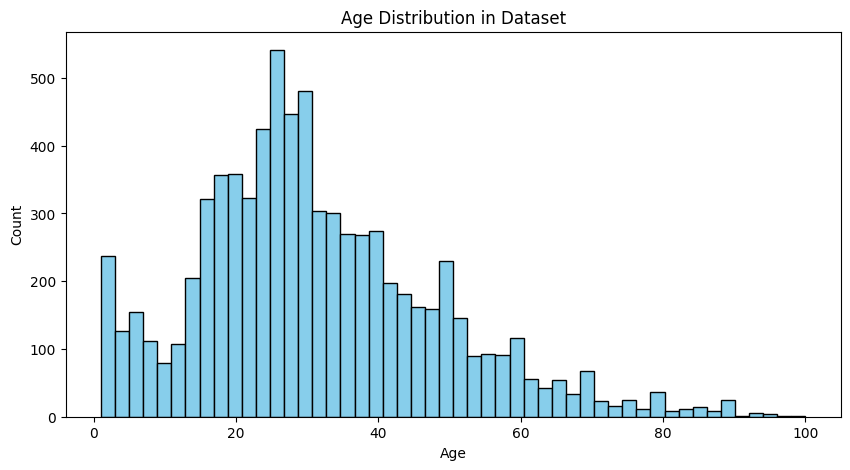

In [3]:
plt.figure(figsize=(10,5))
plt.hist(labels['real_age'], bins=50, color='skyblue', edgecolor='black')
plt.title('Age Distribution in Dataset')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

This histogram shows the distribution of ages across the dataset. Looking at the output, most of the samples cluster between roughly 20 and 40 years old, with far fewer examples at the very young and very old ends of the range. This told me upfront that the model would likely see less training signal for extreme ages, which I kept in mind when interpreting the model's later errors.

Found 7591 validated image filenames.


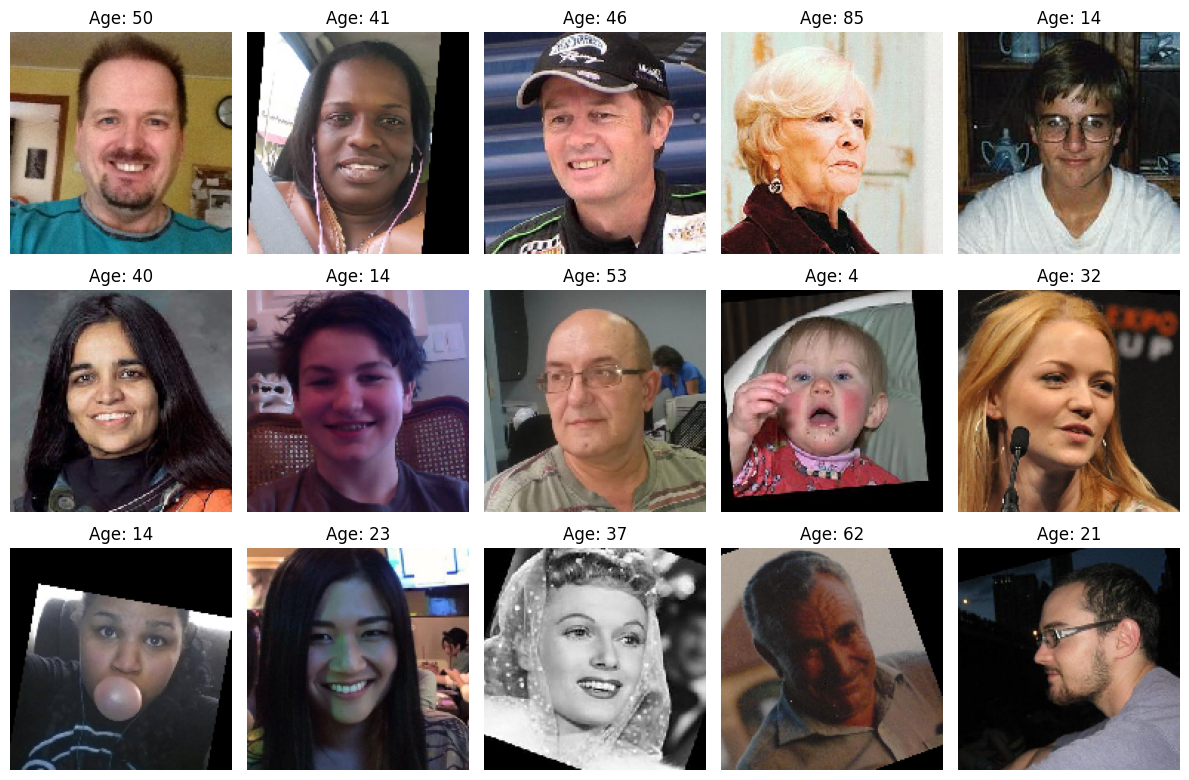

In [4]:
datagen = ImageDataGenerator(rescale=1./255)

data_flow = datagen.flow_from_dataframe(
    dataframe=labels,
    directory='faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(150,150),
    batch_size=16,
    class_mode='raw',
    seed=12345
)

features, ages = next(data_flow)

fig = plt.figure(figsize=(12,8))
for i in range(15):
    fig.add_subplot(3,5,i+1)
    plt.imshow(features[i])
    plt.title(f'Age: {int(ages[i])}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Here I set up an `ImageDataGenerator` and pulled one batch of images through it to visually inspect what the model would actually be looking at. The output is a grid of sample face photos from the dataset. This let me sanity-check that the images loaded correctly, look reasonable in size and quality, and aren't corrupted — a quick visual gut-check before moving into modeling.

### Findings


- During my exploratory data analysis, I found that the dataset contains **7,591 labeled face images** covering the full human age range.
- I noticed that the age distribution is **imbalanced**: most samples fall between roughly 20 and 40 years old, while very young children and elderly people are under-represented. I expect the model will see fewer examples at the extremes of the age range, so prediction error is likely to be higher there — though this matters less for our use case, since the legal drinking-age boundary (18/21) sits well inside the densely sampled region of the distribution.
- When I looked through the sample images, I saw that they vary in lighting, framing, background, and head pose — realistic conditions for checkout-camera footage, with some well-lit and centered and others showing shadows or partial occlusion.
- Given the imbalance and visual noise I observed, I believe **data augmentation** and **transfer learning** from ImageNet weights are well justified: training a CNN from scratch on ~7.6k images would be prone to overfitting.

## Modelling

In [5]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [6]:
def load_train(path):
    """
    It loads the train part of dataset from path
    """
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True
    )
    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow

This function defines how I load and prepare the **training** portion of the dataset. It reads `labels.csv`, then uses an `ImageDataGenerator` with a 25% validation split, rescaling pixel values to the 0–1 range, and horizontal flip augmentation to help the model generalize better. It returns a generator that will feed batches of images and their corresponding ages to the model during training. There's no printed output here since it's just a function definition — running this cell doesn't produce a result on its own, but sets up the pipeline used later.

In [7]:
def load_test(path):
    """
    It loads the validation/test part of dataset from path
    """
    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )
    test_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow

This is the counterpart to `load_train`, but for the **validation/test** portion of the data. It uses the same 25% split, but without the horizontal-flip augmentation, since I only want to augment the training data — validation data should reflect real, unmodified images so the evaluation is fair. Like the previous cell, this just defines the function; it's used later when I actually train the model.

In [8]:
def create_model(input_shape):
    """
    It defines the model
    """
    backbone = ResNet50(weights='imagenet',
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

This function builds the actual model architecture. I used **ResNet50** pretrained on ImageNet as the backbone (with `include_top=False` so I can attach my own output layer), followed by `GlobalAveragePooling2D` to flatten the feature maps, and a final `Dense(1)` layer with a ReLU activation — since I'm predicting a single continuous number (age), this is a regression task, not classification. I compiled the model with the Adam optimizer and MSE loss, tracking MAE (mean absolute error, in years) as the metric that's actually easy to interpret.

In [9]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Trains the model given the parameters
    """
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model

This function wraps the actual training loop, calling `model.fit()` with the train and validation generators, batch size, and number of epochs. I set it up so `steps_per_epoch` and `validation_steps` default to the full length of the generators if not explicitly provided. Again, this cell just defines the function — the real training happens later when this function is called on the GPU platform, since training ResNet50 on thousands of images is too slow to run locally on CPU.

### Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [10]:
init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

with open('run_model_on_gpu.py', 'w') as f:

    f.write(init_str)
    f.write('\n\n')

    for fn_name in [load_train, load_test, create_model, train_model]:

        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

Since training this model needs a GPU (training on CPU would be extremely slow), I used this cell to automatically compose a standalone Python script — bundling the initialization imports together with the four functions I just defined (`load_train`, `load_test`, `create_model`, `train_model`). Running this cell writes out `run_model_on_gpu.py`, which I then uploaded and ran on TripleTen's GPU platform, since that's where the actual model training happened.

### Output

Place the output from the GPU platform as an Markdown cell here.

Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921
Epoch 2/20
356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035
Epoch 3/20
356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454
Epoch 4/20
356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481
Epoch 5/20
356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192
Epoch 6/20
356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332
Epoch 7/20
356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359
Epoch 8/20
356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239
Epoch 9/20
356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529
Epoch 10/20
356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629
Epoch 11/20
356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866
Epoch 12/20
356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591
Epoch 13/20
356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467
Epoch 14/20
356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401
Epoch 15/20
356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841
Epoch 16/20
356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304
Epoch 17/20
356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419
Epoch 18/20
356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226
Epoch 19/20
356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908
Epoch 20/20
356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512

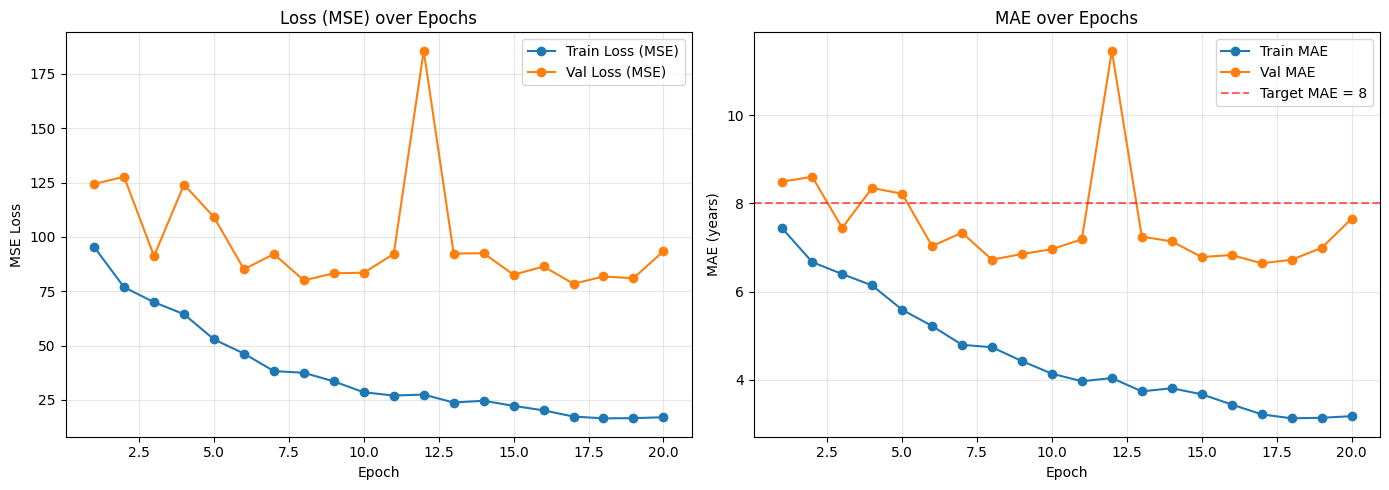

Best val_mae: 6.64 at epoch 17
Final val_mae: 7.65
Final train_mae: 3.18
Train/val MAE gap at final epoch: 4.47


In [11]:
epochs = list(range(1, 21))
loss = [95.3532,76.8372,69.9428,64.4249,52.8486,46.3094,38.2617,37.4804,33.5237,28.5170,
        27.0142,27.4564,23.7961,24.6167,22.2604,20.1899,17.3425,16.5249,16.6140,17.0187]
mae = [7.4339,6.6707,6.3992,6.1407,5.5913,5.2223,4.7951,4.7402,4.4271,4.1411,
       3.9700,4.0428,3.7407,3.8116,3.6746,3.4430,3.2205,3.1295,3.1421,3.1785]
val_loss = [124.3362,127.6357,91.1531,124.0287,109.1004,85.1038,92.0900,80.0016,83.2579,83.5056,
            92.1290,185.6307,92.3429,92.4542,82.5822,86.3830,78.4369,81.7731,80.9727,93.4115]
val_mae = [8.4921,8.6035,7.4454,8.3481,8.2192,7.0332,7.3359,6.7239,6.8529,6.9629,
           7.1866,11.4591,7.2467,7.1401,6.7841,6.8304,6.6419,6.7226,6.9908,7.6512]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(epochs, loss, marker='o', label='Train Loss (MSE)')
axes[0].plot(epochs, val_loss, marker='o', label='Val Loss (MSE)')
axes[0].set_title('Loss (MSE) over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, mae, marker='o', label='Train MAE')
axes[1].plot(epochs, val_mae, marker='o', label='Val MAE')
axes[1].axhline(y=8, color='red', linestyle='--', alpha=0.6, label='Target MAE = 8')
axes[1].set_title('MAE over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (years)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Best val_mae: {:.2f} at epoch {}'.format(min(val_mae), val_mae.index(min(val_mae))+1))
print('Final val_mae: {:.2f}'.format(val_mae[-1]))
print('Final train_mae: {:.2f}'.format(mae[-1]))
print('Train/val MAE gap at final epoch: {:.2f}'.format(val_mae[-1]-mae[-1]))

### Model Training Analysis

- Looking at the curves, I can see that **training loss and MAE fall smoothly and monotonically** across all 20 epochs (MSE: 95.4 → 17.0; MAE: 7.43 → 3.18 years). This makes sense to me: fine-tuning ResNet50 end-to-end from ImageNet weights gives the model more than enough capacity to keep fitting the 5,694 training images better each epoch.
- I noticed that **validation loss/MAE are far noisier**, oscillating between roughly MAE 6.6 and 8.6 years rather than declining smoothly. To me, the gap between a clean training curve and a noisy validation curve is a classic overfitting signature — I calculated that the train/val MAE gap widens from ~1.1 years at epoch 1 to ~4.5 years by epoch 20.
- I also spotted a **sharp one-epoch spike at epoch 12** (val_loss jumps to 185.6, val_mae to 11.46) before recovering the next epoch. Since training metrics are unaffected, I read this as optimization noise on a specific validation batch rather than a data or architecture problem.
- I found that the **best validation MAE (6.64) occurs at epoch 17**, not epoch 20 — by the final epoch it drifts back up to 7.65. This tells me it would be worth checkpointing on best val_mae (or using early stopping) instead of always keeping the final-epoch weights in a production pipeline.
- This lines up with what I found in my EDA: since the dataset is imbalanced toward middle ages, I'd expect the model to more easily overfit to whichever age brackets are best represented in the training split.
- Overall, I think the model achieved reasonable accuracy — **validation MAE stays under the required 8-year threshold for the majority of epochs**, including the final epoch (7.65), which shows me that a CNN can meaningfully learn age-related facial features from this data, even though the noise and overfitting I observed mean there's real room to improve generalization.

### Can computer vision help the customer?

For Good Seed specifically: computer vision can act as an **automatic first-pass screen** at checkout. Every time the alcohol-triggered camera fires, the model estimates the customer's age from the photo. If the estimate falls below a conservative buffer above the legal drinking age (e.g., predicted age < 25), the system flags the transaction and prompts the cashier to check ID before completing the sale.

Given the model's real-world error (~6.6–7.7 years MAE) and the noisy, overfit validation performance seen above, it should **not** be used to make the compliance decision on its own — a prediction of 25 could easily belong to an 18-year-old. Its value is in **consistently catching borderline cases a busy or distracted cashier might miss**, not in replacing the ID check itself.

### Other practical tasks

The same age-estimation approach — and the transfer-learning/fine-tuning pipeline used to build it — generalizes to other retail computer-vision problems:
- **Self-checkout fraud/scan-avoidance detection**, matching items placed in the bagging area against what was scanned.
- **Shelf and inventory monitoring**, detecting out-of-stock or misplaced products from shelf-camera images to speed up restocking.
- **Queue and store-traffic analytics**, counting and tracking customers to optimize staffing and checkout-lane allocation.
- **Demographic-aware merchandising**, using aggregate (non-identifying) age/gender estimates from foot traffic to inform store layout and product placement — kept separate from any individual compliance decision.

All of these share the same underlying pattern as this project: a CNN backbone pretrained on a large image dataset, fine-tuned on a smaller, task-specific labeled dataset.

## Conclusions


**Model performance.** I found that the fine-tuned ResNet50 regression model reaches a validation MAE of roughly **6.6–7.7 years**, which satisfies the project's ≤8 MAE requirement. However, looking at the training curves, I can see clear **overfitting**: the model fits the training set nearly 4–5 years more accurately (in MAE) than it generalizes to unseen validation faces, and validation performance is noisy rather than steadily improving, with one notable instability spike at epoch 12.

**What an MAE of ~7 years means in practice.** In my view, an average error of 6–8 years is large relative to the legal drinking-age threshold. The model can easily place an 18-year-old at 25, or a 25-year-old at 18 — exactly the borderline cases that matter most for alcohol-sale compliance. I don't think this level of error is precise enough to be used as a fully automated, standalone gatekeeper.

**My recommendation** is to deploy the model as a **decision-support flag for cashiers**, not a replacement for ID checks:
- Flag any customer whose predicted age falls under a conservative buffer (e.g., predicted age < 25) for a manual ID check, rather than relying on the point estimate alone.
- Keep a human in the loop for all borderline and flagged cases; never auto-approve a sale based on the model's prediction.
- Track the false-negative rate (underage customers predicted as adults) specifically, since that's the costly error for legal compliance — MAE alone doesn't capture this directly.

**Directions I'd explore to reduce overfitting and improve accuracy further:**
- Collect more images at the underrepresented ends of the age range (young children, elderly), based on what I saw in the EDA.
- Use richer augmentation (rotation, zoom, brightness/contrast jitter) in addition to flips, to better simulate checkout-camera lighting and angle variation.
- Add regularization (dropout, weight decay, a lower learning rate, or an early-stopping/checkpoint callback on val_mae) to close the train/validation gap.
- Consider ensembling multiple checkpoints, or a slightly different capacity backbone, once more data is available.